### *SENTIMENT ANALYSIS*

*Sentiment analysis, also known as opinion mining, is a natural language processing (NLP) technique used to determine whether data has a positive, negative, or neutral sentiment. It involves analyzing text to identify and extract subjective information from sources such as social media posts, product reviews, and, in this case, restaurant reviews. Sentiment analysis is widely applied in various industries to gauge customer opinions, improve products or services, and make data-driven decisions. With the rise of big data and social media, sentiment analysis has become a crucial tool for understanding and leveraging human emotions at scale.*

### *WHY WE USE SENTIMENT ANALYSIS*

*  **Customer Feedback:** *Analyze opinions to improve products and services.*
*  **Brand Monitoring:** *Track and manage brand reputation in real-time.*
*  **Market Insights:** *Identify trends and consumer preferences for strategy.*
*  **Enhance Experience:** *Personalize and improve customer satisfaction.*
*  **Social Media Analysis:** *Evaluate public opinion and measure the impact of campaigns or events.*



### *APPLICATIONS OF SENTIMENT ANALYSIS*
* **Customer Service:** *Automatically categorize and prioritize customer queries based on sentiment.*
* **Market Research:** *Understand public sentiment towards products, brands, or services for strategic planning.*
* **Social Media Monitoring:** *Analyze posts and trends to measure the impact of campaigns or events.*
* **Political Analysis:** *Gauge public sentiment on policies, candidates, or election outcomes.*
* **Product Development:** *Use customer feedback to enhance features and address pain points.*
* **Healthcare:** *Identify emotional distress in patient feedback or health-related discussions.*

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np  # linear algebra
import pandas as pd  # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/restaurant-reviews/Restaurant reviews.csv


## *IMPORT NECESSARY LIBRARIES*

In [ ]:
import pandas as pd  # pandas library for data manipulation and analysis
import numpy as np  # NumPy library, which supports large, multi-dimensional arrays and matrices
import matplotlib.pyplot as plt  # Matplotlib library, for visualizations like plots and charts
import seaborn as sns  # Seaborn library, a statistical data visualization library based on Matplotlib, which provides a high-level interface for drawing attractive and informative statistical graphics
import tensorflow as tf  # TensorFlow library, an open-source machine learning framework
import tensorflow_text as tft  # TensorFlow Text, an extension library for handling text preprocessing and tokenization tasks in TensorFlow
import re  # Regular Expressions (regex) library, which is used for string searching and manipulation
import warnings  # warnings module, which handles warning messages in the code

warnings.filterwarnings(
    "ignore"
)  # suppresses the warning messages to make the output clear
import nltk  # Natural Language Toolkit (NLTK), a library for working with human language data (text)

nltk.download(
    "stopwords"
)  # Downloads the list of stopwords from the NLTK library. Stopwords are common words (like "the", "is", "in") that are often removed in NLP tasks because they don't carry much meaning
from nltk.corpus import stopwords  # Imports the stopwords list from the NLTK corpus

plt.rcParams["figure.figsize"] = (18, 12)  # Sets the default size for plots

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## *IMPORT THE DATASET*

In [ ]:
df = pd.read_csv("/kaggle/input/restaurant-reviews/Restaurant reviews.csv")

In [ ]:
df.head()  # returns the first 5rows of the DataFrame df for understanding its structure

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures,7514
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0,2447.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0,NaN
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0,NaN
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0,NaN
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0,NaN


In [ ]:
df.info()  # provides info of no.of rows and columns, datatypes, column names, memory usage...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Restaurant  10000 non-null  object 
 1   Reviewer    9962 non-null   object 
 2   Review      9955 non-null   object 
 3   Rating      9962 non-null   object 
 4   Metadata    9962 non-null   object 
 5   Time        9962 non-null   object 
 6   Pictures    10000 non-null  int64  
 7   7514        1 non-null      float64
dtypes: float64(1), int64(1), object(6)
memory usage: 625.1+ KB


In [ ]:
df["Rating"].value_counts()  # selects the Rating and counts the no.of occurrences

Rating
5       3832
4       2373
1       1735
3       1193
2        684
4.5       69
3.5       47
2.5       19
1.5        9
Like       1
Name: count, dtype: int64

## *DATA CLEANING*

In [ ]:
df[
    df["Rating"] == "Like"
].index  # This filters the DataFrame, returning only the rows where the Rating is 'Like'

Index([7601], dtype='int64')

In [ ]:
df.drop(
    index=df[df["Rating"] == "Like"].index, inplace=True
)  # where the Rating column has the value 'Like' will be removed

In [ ]:
df["Rating"] = df["Rating"].apply(
    float
)  # converts the each value in the Rating to a floating-point number

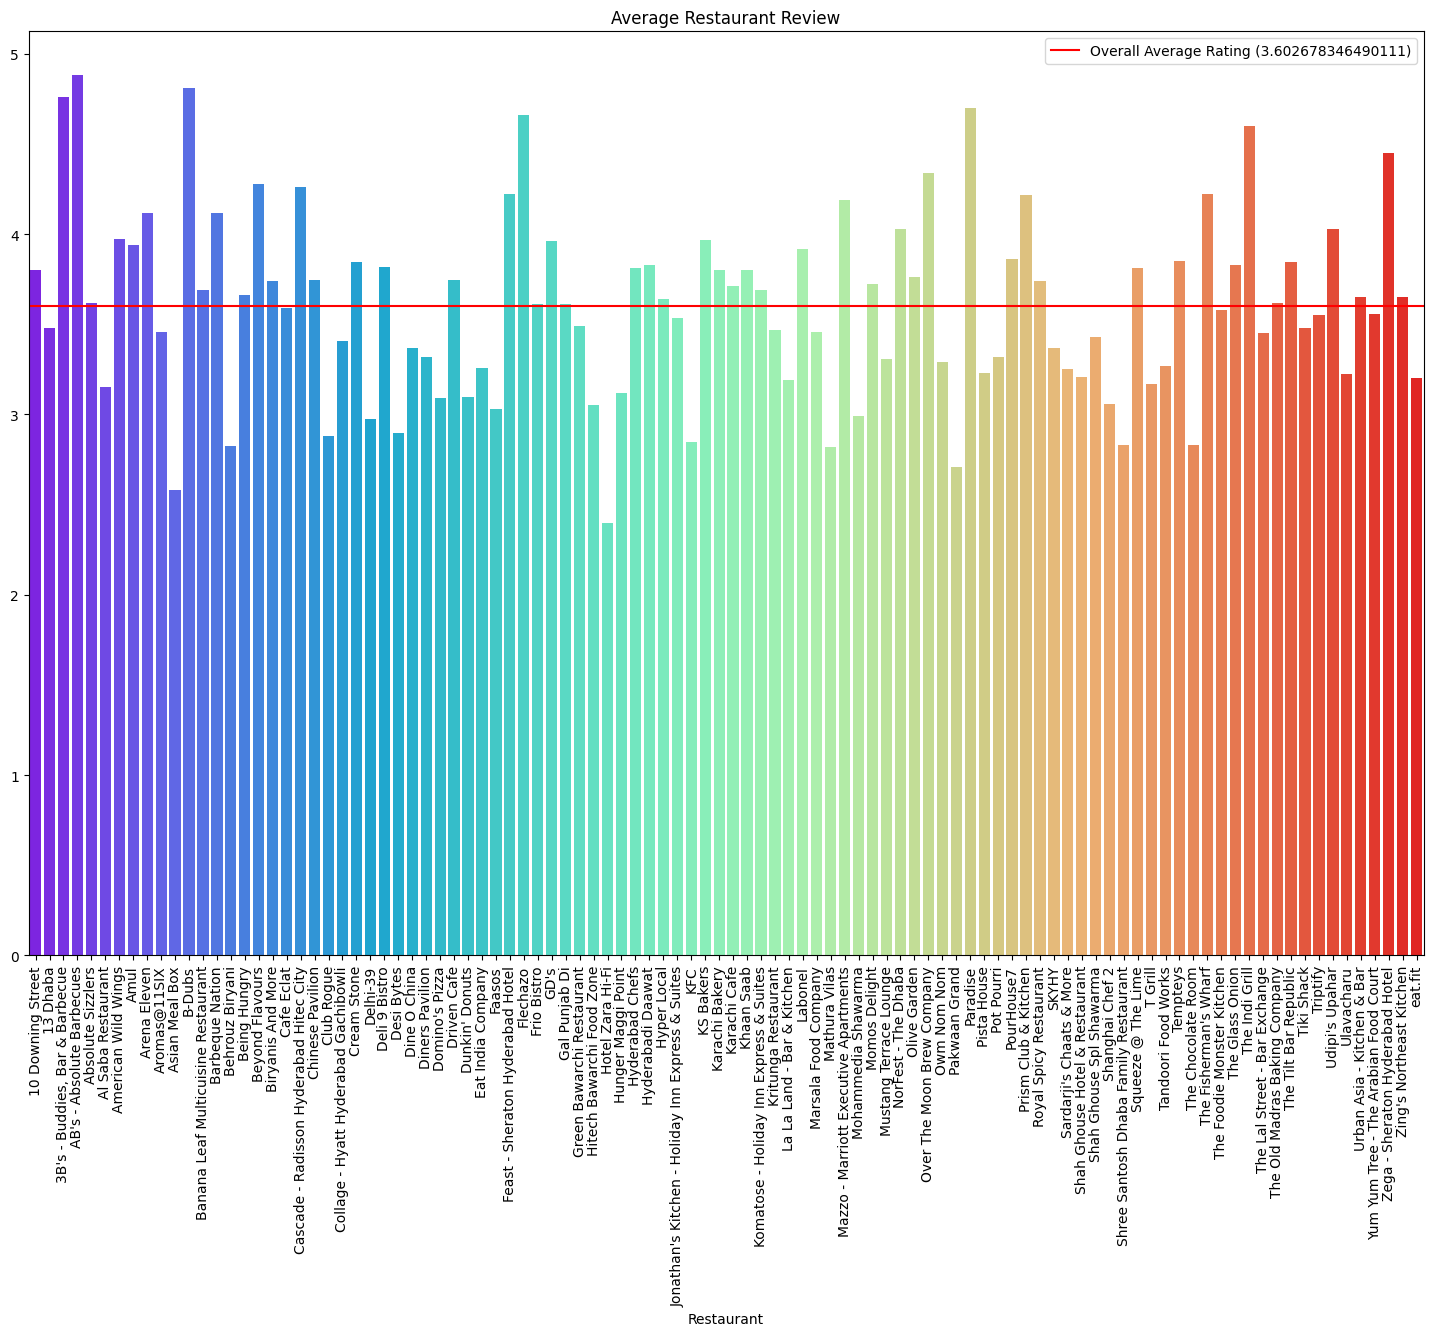

In [ ]:
# calculating the average rating for each restaurant
avg_rating = df.groupby("Restaurant")["Rating"].mean()
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette="rainbow")
plt.axhline(
    np.mean(avg_rating.values),
    color="red",
    label=f"Overall Average Rating ({np.mean(avg_rating.values)})",
)
plt.xticks(rotation=90)
plt.legend()
plt.title("Average Restaurant Review")
plt.show()

In [ ]:
data = df[["Restaurant", "Reviewer", "Review", "Rating"]]  # displays only these columns
data.head()

,Restaurant,Reviewer,Review,Rating
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0


## *TEXT PREPROCESSING*

#### *Text Cleaning*

In [ ]:
# 'clean_text' that processes and cleans text data
stop = set(stopwords.words("english"))


def clean_text(txt, stop=stop):
    if not isinstance(txt, str):
        txt = str(txt)
    txt = txt.lower()
    txt = re.sub(r"\\[nt]*", " ", txt)  # removes \n and \t tags
    txt = re.sub(r"[^A-Za-z\s]", " ", txt)  # removes numbers and other non textual data
    txt = re.sub(r"[\s+]", " ", txt)  # removes multiple whitespaces
    txt = " ".join([x for x in txt.split(" ") if x not in stop])
    return txt

In [ ]:
data["clean_review"] = data["Review"].apply(
    clean_text
)  # applies the 'clean_text' function to each entry in the Review column of the DataFrame data and creates a new column called 'clean_review'

#### *Target Variable Creation*

In [ ]:
data["Target"] = data["Rating"].apply(
    lambda x: 0 if x > 3.0 else 1
)  # 0 indicates that the rating value is > 3.0, whereas 1 indicates the rating value is <3.0
data.head()

,Restaurant,Reviewer,Review,Rating,clean_review,Target
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,ambience good food quite good saturday lunc...,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,ambience good pleasant evening service prompt...,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,must try great food great ambience thnx ser...,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,soumen das arun great guy behavior sincerety ...,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,food good ordered kodi drumsticks basket mutto...,0


In [ ]:
import spacy

# By using import spacy, you can access a wide range of powerful NLP tools that facilitate tasks such as text analysis, information extraction, and understanding language structure, making it a valuable resource for data scientists and developers working with textual data.

### **Lemmatization:** 
*Lemmatization is the process of reducing a word to its base or root form while keeping its meaning. For example, words like "running," "runs," and "ran" are all reduced to their root form, "run."*

*It helps make text easier to analyze in tasks like sentiment analysis or text classification because it groups similar words together.*

In [ ]:
# Lemmatization helps reduce words to their base forms, which can improve the performance of models in tasks such as sentiment analysis, topic modeling, or any text classification task

nlp = spacy.load("en_core_web_sm")


def lemmatize_review(txt, nlp=nlp):
    words = nlp(txt)
    txt = " ".join(word.lemma_ for word in words)
    return txt

In [ ]:
data["clean_review"] = data["clean_review"].apply(lemmatize_review)

# example of clean_review and lemmatized_review : He went to the stores is a clean_review, he go to the store is a lemmatized_review

In [18]:
data.head()

,Restaurant,Reviewer,Review,Rating,clean_review,Target
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5.0,ambience good food quite good saturday lu...,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5.0,ambience good pleasant evening service promp...,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5.0,must try great food great ambience thnx s...,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5.0,soumen das arun great guy behavior sincerety...,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5.0,food good order kodi drumstick basket mutton b...,0


In [ ]:
def preprocess_text_for_pred(
    txt,
):  # The preprocess_text_for_pred function combines text cleaning and lemmatization into a single preprocessing pipeline
    txt = clean_text(txt)
    nlp = spacy.load("en_core_web_sm")
    txt = lemmatize_review(txt, nlp)
    return txt

## *DATASET PREPARATION*

In [ ]:
X = data["clean_review"].to_numpy()
Y = data["Target"].to_numpy()
dataset = tf.data.Dataset.from_tensor_slices((X, Y))

In [ ]:
split = int(len(data) * 0.8)
train = dataset.take(split)
val = dataset.skip(split)

In [ ]:
train = (
    train.batch(64)
    .prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000)
)
val = (
    val.batch(64)
    .prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    .cache()
    .shuffle(buffer_size=1000)
)

## *MODEL CREATION AND TRAINING*

In [ ]:
max_tok = 10000
Vect = tf.keras.layers.TextVectorization(max_tokens=max_tok)
Vect.adapt(dataset.map(lambda x, y: x))

In [ ]:
model = tf.keras.models.Sequential(
    [
        Vect,
        tf.keras.layers.Embedding(len(Vect.get_vocabulary()), 128, mask_zero=True),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
        tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(1, activation=None),
    ]
)
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
    metrics=["Accuracy"],
)

In [ ]:
es_cb = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)

In [ ]:
history = model.fit(
    train, batch_size=64, validation_data=val, epochs=50, callbacks=[es_cb]
)
# If the validation loss does not improve for 3 consecutive epochs, training will stop.

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 83s 591ms/step - Accuracy: 0.7382 - loss: 0.5297 - val_Accuracy: 0.8270 - val_loss: 0.3497
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 72s 581ms/step - Accuracy: 0.8997 - loss: 0.2555 - val_Accuracy: 0.8335 - val_loss: 0.3587
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 73s 582ms/step - Accuracy: 0.9411 - loss: 0.1617 - val_Accuracy: 0.8380 - val_loss: 0.3891
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 82s 581ms/step - Accuracy: 0.9541 - loss: 0.1253 - val_Accuracy: 0.8305 - val_loss: 0.4071


## *VISUALIZATION*

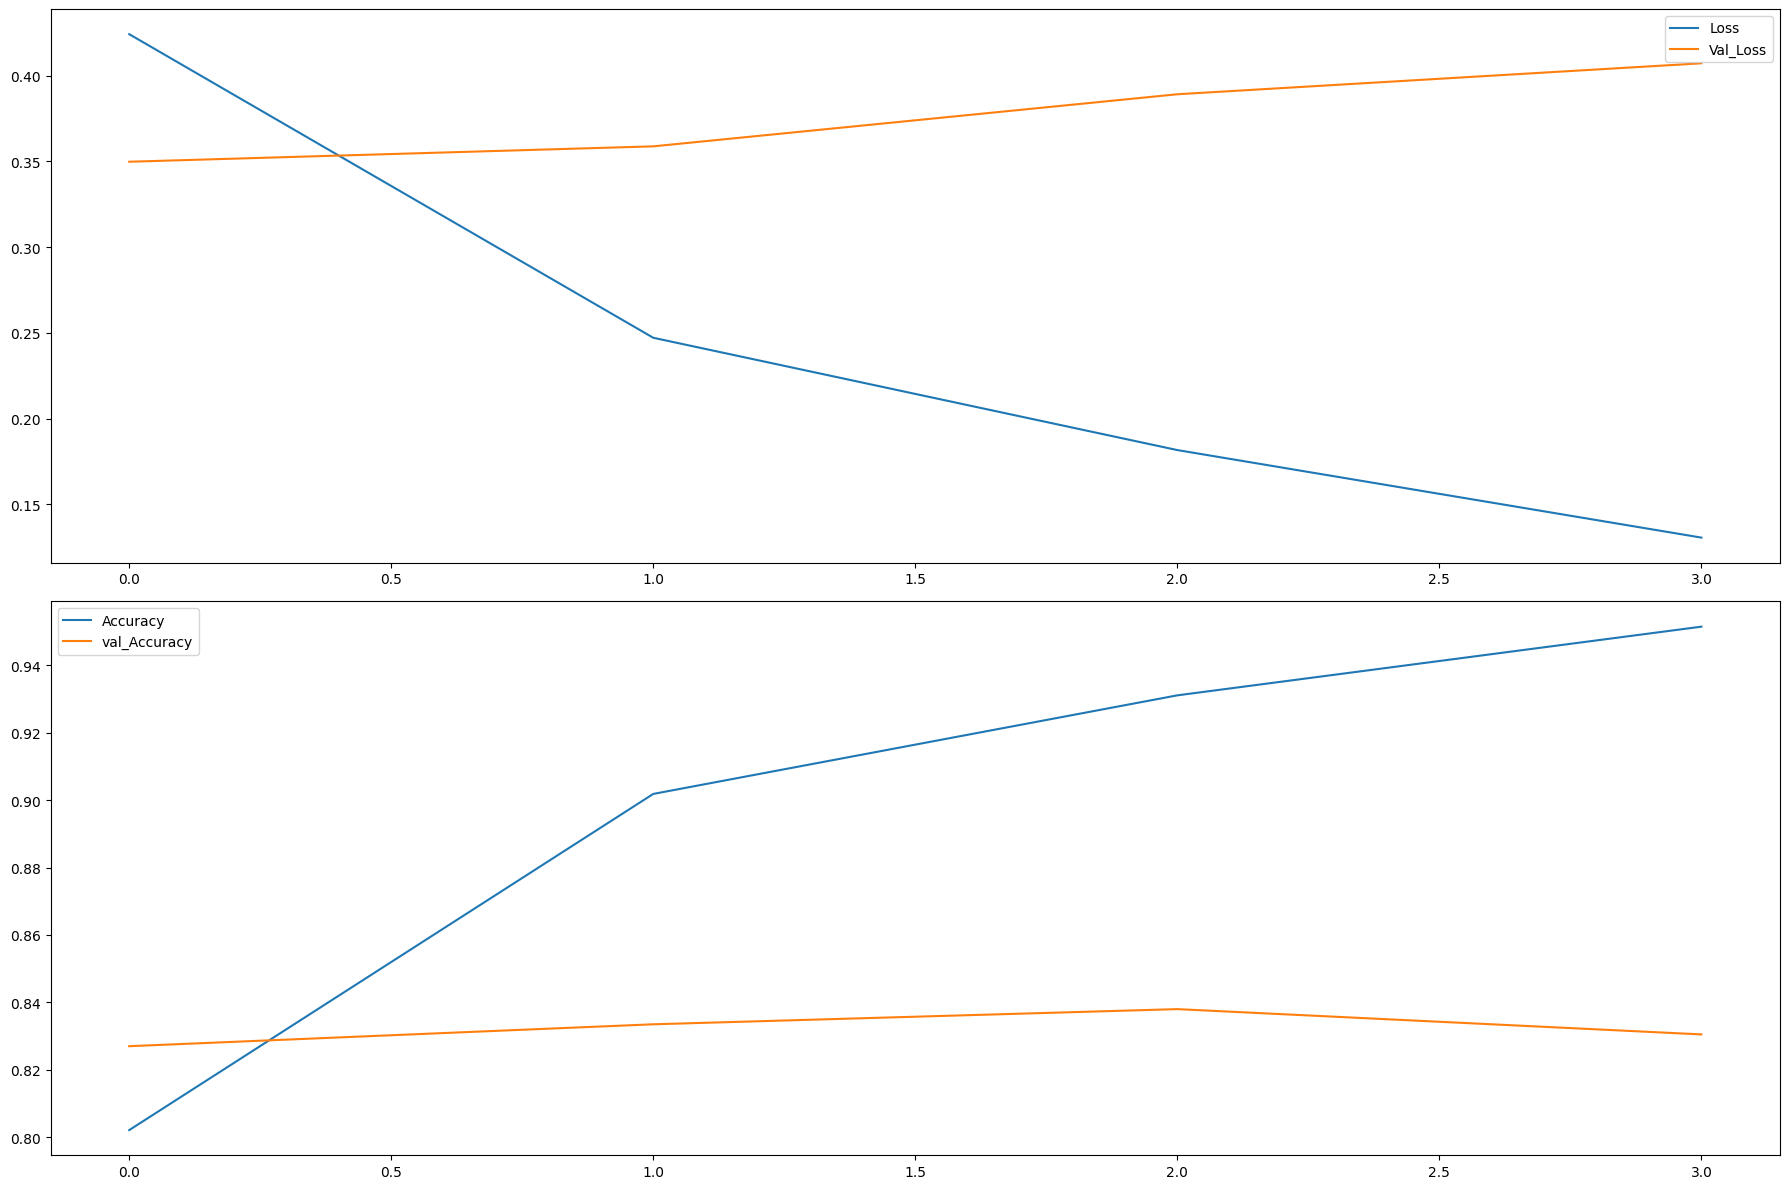

In [ ]:
def plot_hist(history):
    hist = history.history
    plt.subplot(2, 1, 1)
    plt.plot(range(len(hist["loss"])), hist["loss"], label="Loss")
    plt.plot(range(len(hist["val_loss"])), hist["val_loss"], label="Val_Loss")
    plt.legend()
    plt.subplot(2, 1, 2)
    plt.plot(range(len(hist["Accuracy"])), hist["Accuracy"], label="Accuracy")
    plt.plot(
        range(len(hist["val_Accuracy"])), hist["val_Accuracy"], label="val_Accuracy"
    )
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_hist(history)

In [ ]:
# Check positive reviews
positive_reviews = data[data["Target"] == 0]
print("Positive Reviews:")
print(
    positive_reviews[["Restaurant", "Reviewer", "Review", "Rating"]].head()
)  # Display first few positive reviews

# Check negative reviews
negative_reviews = data[data["Target"] == 1]
print("\nNegative Reviews:")
print(
    negative_reviews[["Restaurant", "Reviewer", "Review", "Rating"]].head()
)  # Display first few negative reviews


Positive Reviews:
        Restaurant              Reviewer  \
0  Beyond Flavours     Rusha Chakraborty   
1  Beyond Flavours  Anusha Tirumalaneedi   
2  Beyond Flavours       Ashok Shekhawat   
3  Beyond Flavours        Swapnil Sarkar   
4  Beyond Flavours                Dileep   

                                              Review  Rating  
0  The ambience was good, food was quite good . h...     5.0  
1  Ambience is too good for a pleasant evening. S...     5.0  
2  A must try.. great food great ambience. Thnx f...     5.0  
3  Soumen das and Arun was a great guy. Only beca...     5.0  
4  Food is good.we ordered Kodi drumsticks and ba...     5.0  

Negative Reviews:
         Restaurant       Reviewer  \
14  Beyond Flavours  Kankaria.ritu   
30  Beyond Flavours   Pragya Sarda   
45  Beyond Flavours        Sind Hu   
56  Beyond Flavours    Dyagamrahul   
66  Beyond Flavours    Tejaswi Rao   

                                               Review  Rating  
14  We ordered corn cheese 

## *REVIEW CLASSIFICATION AND VISUALIZATION*

#### *Classify Individual Review*

In [ ]:
def classify_review(review, model):
    # Preprocess the input review
    cleaned_review = preprocess_text_for_pred(review)  # Use your preprocessing function
    review_array = np.array([cleaned_review])  # Convert to numpy array
    review_tensor = tf.data.Dataset.from_tensor_slices(review_array).batch(
        1
    )  # Create a tensor dataset

    # Make a prediction
    prediction = model.predict(review_tensor)
    predicted_class = (
        0 if prediction[0] < 0 else 1
    )  # Use the threshold (0 for positive, 1 for negative)

    return "Positive Review" if predicted_class == 0 else "Negative Review"


# Example usage
input_review = "The food was fantastic and the service was excellent!"
result = classify_review(input_review, model)
print(result)  # Output: Positive Review


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 745ms/step
Positive Review


In [30]:
input_review = "The food was bad"
result = classify_review(input_review, model)
print(result)  # Output: Positive Review

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Negative Review


In [ ]:
import numpy as np
import tensorflow as tf
from IPython.display import display, HTML


def classify_review(review, model):
    # Preprocess the input review
    cleaned_review = preprocess_text_for_pred(review)  # Use your preprocessing function
    review_array = np.array([cleaned_review])  # Convert to numpy array
    review_tensor = tf.data.Dataset.from_tensor_slices(review_array).batch(
        1
    )  # Create a tensor dataset

    # Make a prediction
    prediction = model.predict(review_tensor)
    predicted_class = (
        0 if prediction[0] < 0 else 1
    )  # Use the threshold (0 for positive, 1 for negative)

    return predicted_class  # Return class


def display_review_result(review):
    predicted_class = classify_review(review, model)

    if predicted_class == 0:
        # Positive Review
        display(
            HTML(
                f"<span style='color: green; font-size: 20px;'>👍 Positive Review: {review}</span>"
            )
        )
    else:
        # Negative Review
        display(
            HTML(
                f"<span style='color: red; font-size: 20px;'>👎 Negative Review: {review}</span>"
            )
        )


# Example usage
input_review = "The food was fantastic and the service was excellent!"
display_review_result(input_review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [32]:
# Example usage for a negative review
input_review = "The service was terrible and the food was cold."
display_review_result(input_review)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


#### *Visualize Positive vs Negative Reviews*

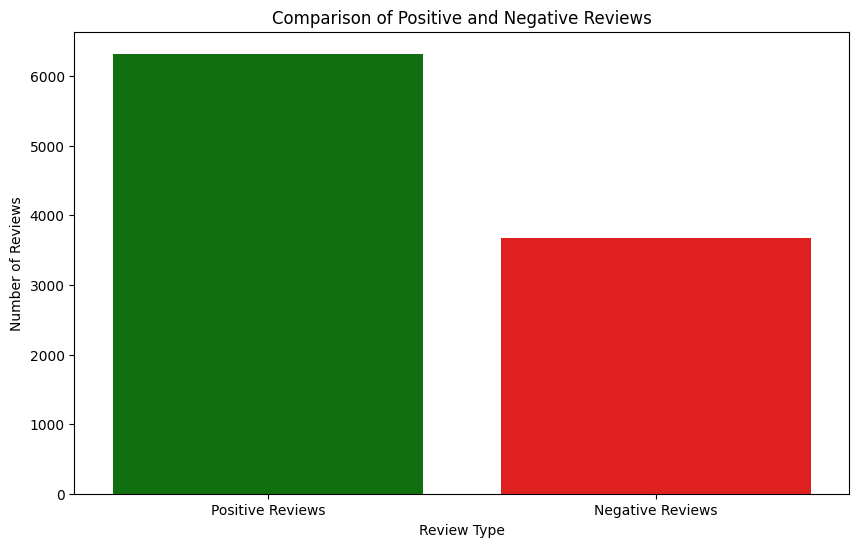

In [ ]:
# Count the number of positive and negative reviews
review_counts = data["Target"].value_counts()

# Map the counts to labels
labels = ["Positive Reviews", "Negative Reviews"]
counts = [review_counts[0], review_counts[1]]

# Plotting the bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x=labels, y=counts, palette=["green", "red"])

# Adding titles and labels
plt.title("Comparison of Positive and Negative Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")

# Display the plot
plt.show()

#### *Restaurant-Wise Analysis*

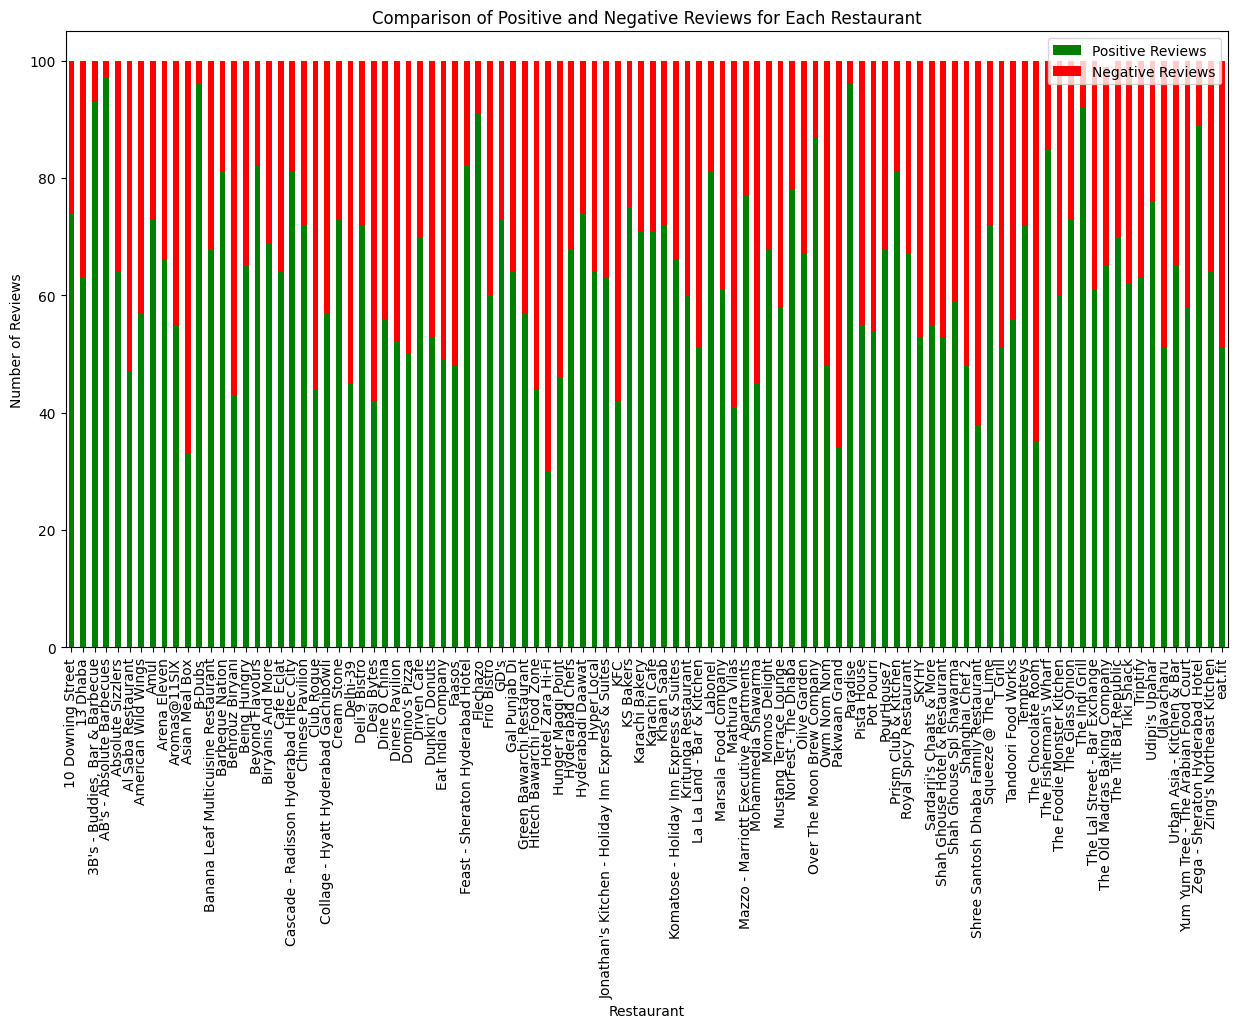

In [ ]:
# Count the number of positive and negative reviews of each restaurant

# Group by 'Restaurant' and 'Target' and count the reviews
restaurant_reviews = data.groupby(["Restaurant", "Target"]).size().unstack(fill_value=0)

# Rename the columns for better readability
restaurant_reviews.columns = ["Positive Reviews", "Negative Reviews"]

# Plotting the bar graph
restaurant_reviews.plot(
    kind="bar", stacked=True, figsize=(15, 8), color=["green", "red"]
)

# Adding titles and labels
plt.title("Comparison of Positive and Negative Reviews for Each Restaurant")
plt.xlabel("Restaurant")
plt.ylabel("Number of Reviews")

# Rotate x labels for readability
plt.xticks(rotation=90)

# Display the plot
plt.show()

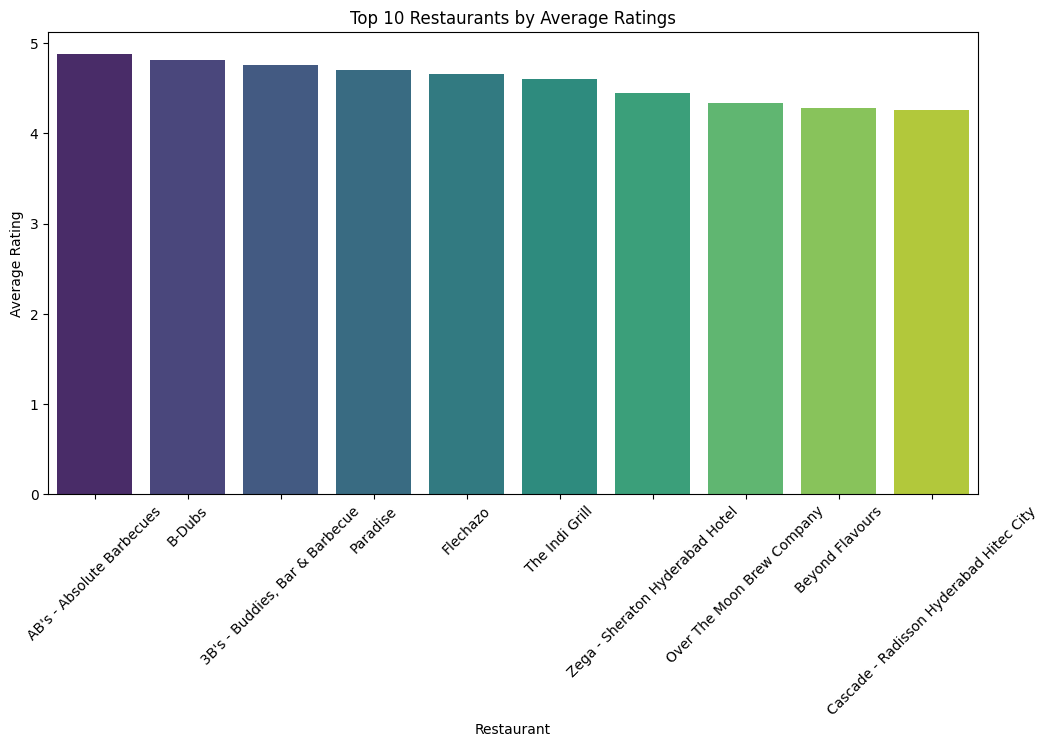

In [ ]:
# Top 10 restaurants with the highest average ratings

# Calculate average ratings for each restaurant
avg_ratings = df.groupby("Restaurant")["Rating"].mean()

# Get the top 10 restaurants with the highest average ratings
top_10_restaurants = avg_ratings.nlargest(10)

# Plotting the bar graph
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_restaurants.index, y=top_10_restaurants.values, palette="viridis")

# Adding titles and labels
plt.title("Top 10 Restaurants by Average Ratings")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")

# Rotate x labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

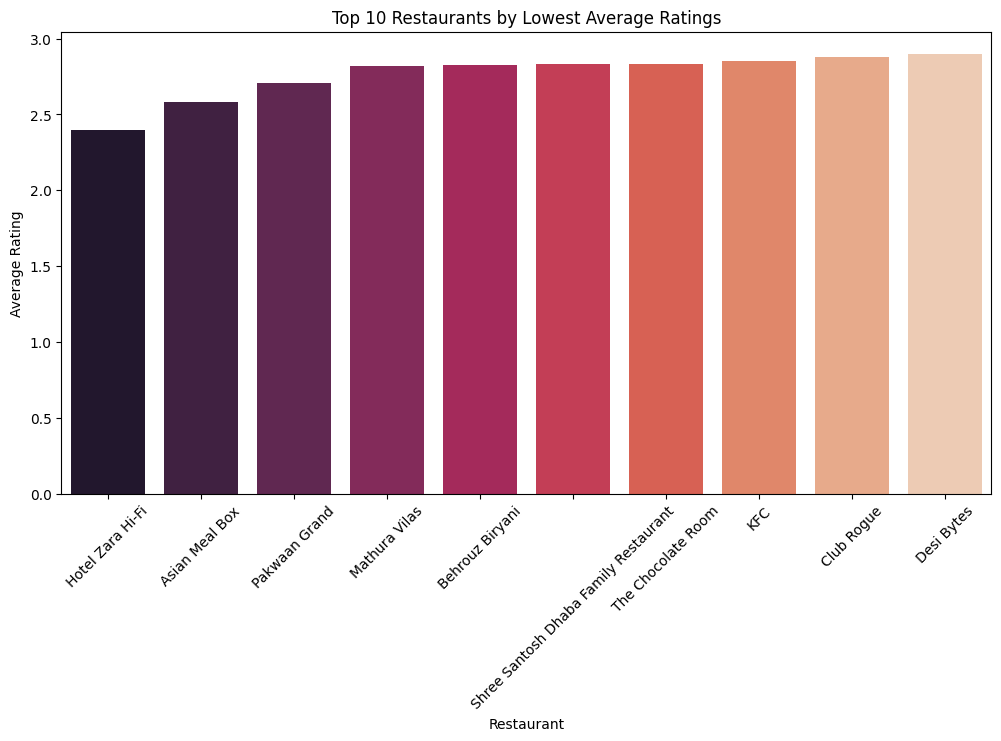

In [ ]:
# Top 10 Restaurants by Lowest Average Ratings

# Calculate average ratings for each restaurant
avg_ratings = df.groupby("Restaurant")["Rating"].mean()

# Get the top 10 restaurants with the lowest average ratings
bottom_10_restaurants = avg_ratings.nsmallest(10)

# Plotting the bar graph
plt.figure(figsize=(12, 6))
sns.barplot(
    x=bottom_10_restaurants.index, y=bottom_10_restaurants.values, palette="rocket"
)

# Adding titles and labels
plt.title("Top 10 Restaurants by Lowest Average Ratings")
plt.xlabel("Restaurant")
plt.ylabel("Average Rating")

# Rotate x labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()

32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 158ms/step


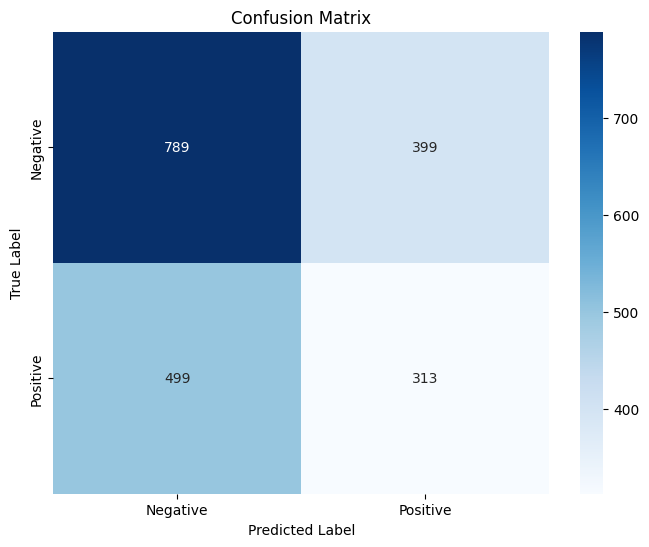

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Make predictions on the validation set
y_pred_logits = model.predict(val.map(lambda x, y: x))  # Get logits
y_pred = (
    (tf.sigmoid(y_pred_logits) > 0.5).numpy().astype(int)
)  # Convert logits to binary predictions

# Get true labels from the validation set
y_true = []
for _, labels in val:
    y_true.extend(labels.numpy())  # Extend the list with true labels

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## *SAVE THE MODEL*

In [ ]:
# Save the trained model
model.save("restaurant_review_model.h5")  # Save as an HDF5 file
print("Model saved successfully!")

Model saved successfully!
